In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
from scipy.optimize import curve_fit
import pylandau

In [2]:
file1 = "/Users/hongc/Geant4/NewPhysicsAt2x2/build/Muon_0.root"
file2 = "/Users/hongc/Geant4/NewPhysicsAt2x2/build/Muon_rand.root"
tree = "PixelEDep"
branch = "EnergyDep"   # or "EnergyDep_Primary"
e1 = uproot.open(file1)[tree][branch].array(library="np")
e2 = uproot.open(file2)[tree][branch].array(library="np")
e1 = e1[e1 > 0]
e2 = e2[e2 > 0]

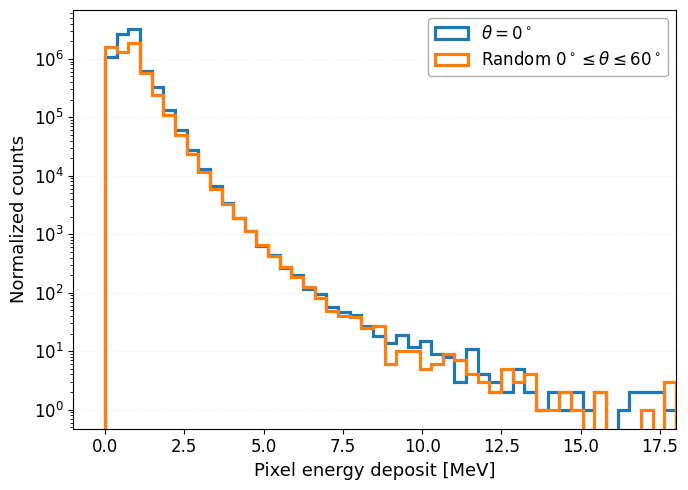

In [3]:
bins = np.linspace(0, 18, 50)
plt.figure(figsize=(7,5))
plt.hist(e1, bins=bins, histtype="step",
         color="tab:blue", linewidth=2.3,
         label=r"$\theta=0^\circ$")

plt.hist(e2, bins=bins, histtype="step",
         color="tab:orange", linewidth=2.3,
         label=r"Random $0^\circ\leq\theta\leq60^\circ$")
plt.xlabel("Pixel energy deposit [MeV]", fontsize=13)
plt.ylabel("Normalized counts", fontsize=13)
plt.xlim(-1,18)
plt.yscale("log")
plt.tick_params(axis="both", which="major", labelsize=12)
plt.grid(axis="y", which="major", linestyle=":", alpha=0.25)
plt.legend(fontsize=12, frameon=True,
           facecolor="white", edgecolor="0.6")
plt.tight_layout()
plt.show()

In [4]:
path = "/Users/hongc/Geant4/NewPhysicsAt2x2/cosmic_mu/packet-0060154-2025_11_20_07_55_40_CST.FLOW.hdf5"
f = h5py.File(path, "r")
Num_track=len(f["analysis/rock_muon_tracks/data"])

In [5]:
def obtain_muon_q(f, track_index, qmin=0.0):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    all_hits, ev_idx = get_track_event_hits(f, track_index)

    if len(all_hits) == 0:
        return np.array([])

    Q = all_hits["Q"]

    mask = np.isfinite(Q) & (Q >= qmin)

    return Q[mask]

In [6]:
def slice_from_ref_region(dset, ref_region_row):
    start = int(ref_region_row["start"])
    stop  = int(ref_region_row["stop"])
    return dset[start:stop]
def point_to_segment_distance(P, A, B):
    # P: (N,3) points; A,B: (3,) endpoints
    AB = B - A
    AP = P - A
    denom = np.dot(AB, AB)
    if denom == 0:
        return np.linalg.norm(P - A, axis=1)
    t = (AP @ AB) / denom
    t = np.clip(t, 0.0, 1.0)
    proj = A + t[:,None] * AB[None,:]
    return np.linalg.norm(P - proj, axis=1)
def get_event_hits_by_event_index(f, event_index):
    hits = f["charge/calib_prompt_hits/data"]
    rr   = f["charge/events/ref/charge/calib_prompt_hits/ref_region"]
    return slice_from_ref_region(hits, rr[event_index])
def find_event_index_from_event_id(f, event_id):
    ev = f["charge/events/data"]
    # common patterns: either event_id matches ev["id"], or it’s just an index
    if "id" in ev.dtype.names:
        m = np.where(ev["id"] == event_id)[0]
        if len(m): 
            return int(m[0])
    # fallback: if event_id looks like an index
    if 0 <= int(event_id) < len(ev):
        return int(event_id)
    raise ValueError("Couldn't map rock_muon_tracks.event_id to charge/events")    
def get_track_event_hits(f, track_index):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    ev_idx = find_event_index_from_event_id(f, tr["event_id"])
    return get_event_hits_by_event_index(f, ev_idx), ev_idx 

In [7]:
MODULE_BOXES = [
    {"module": 0, "xmin":  3.07, "xmax": 63.93, "ymin": -61.85, "ymax": 61.85, "zmin":  2.68, "zmax": 64.32},
    {"module": 1, "xmin":  3.07, "xmax": 63.93, "ymin": -61.85, "ymax": 61.85, "zmin": -64.32, "zmax": -2.68},
    {"module": 2, "xmin": -63.93, "xmax": -3.07, "ymin": -61.85, "ymax": 61.85, "zmin":  2.68, "zmax": 64.32},
    {"module": 3, "xmin": -63.93, "xmax": -3.07, "ymin": -61.85, "ymax": 61.85, "zmin": -64.32, "zmax": -2.68},
]

In [8]:
def point_on_boundary_of_box(p, box, tol=1.0):

    x, y, z = map(float, p)

    # must be inside the box (allow tol slack), otherwise cannot be on its boundary
    if not (box["xmin"]-tol <= x <= box["xmax"]+tol and
            box["ymin"]-tol <= y <= box["ymax"]+tol and
            box["zmin"]-tol <= z <= box["zmax"]+tol):
        return set()

    faces = set()
    if abs(x - box["xmin"]) <= tol: faces.add("xmin")
    if abs(x - box["xmax"]) <= tol: faces.add("xmax")
    if abs(y - box["ymin"]) <= tol: faces.add("ymin")
    if abs(y - box["ymax"]) <= tol: faces.add("ymax")
    if abs(z - box["zmin"]) <= tol: faces.add("zmin")
    if abs(z - box["zmax"]) <= tol: faces.add("zmax")
    return faces

In [9]:
def endpoint_touches_boundary(p, tol=1.0):
    """
    Returns list of matches: [{"module": m, "faces": {...}}, ...]
    Empty list => not on any module boundary.
    """
    out = []
    for box in MODULE_BOXES:
        faces = point_on_boundary_of_box(p, box, tol=tol)
        if faces:
            out.append({"module": box["module"], "faces": faces})
    return out

def both_endpoints_on_boundary(p_start, p_end, tol=1.0):
    """
    Returns (ok, start_info, end_info)
    ok=True iff both endpoints touch at least one module boundary.
    """
    start_info = endpoint_touches_boundary(p_start, tol=tol)
    end_info   = endpoint_touches_boundary(p_end,   tol=tol)
    ok = (len(start_info) > 0) and (len(end_info) > 0)
    return ok

In [10]:
q=[]
for track_index in range(len(f["analysis/rock_muon_tracks/data"])):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    all_hits, ev_idx = get_track_event_hits(f, track_index)
    A = np.array([tr["x_start"], tr["y_start"], tr["z_start"]], dtype=float)
    B = np.array([tr["x_end"], tr["y_end"], tr["z_end"]], dtype=float)
    through = both_endpoints_on_boundary(A,B,tol=1.0)
    if (through):
        Q =  obtain_muon_q(f, track_index, qmin=0.0)
        q.append(Q)
q = np.concatenate(q) if len(q) > 0 else np.array([])        

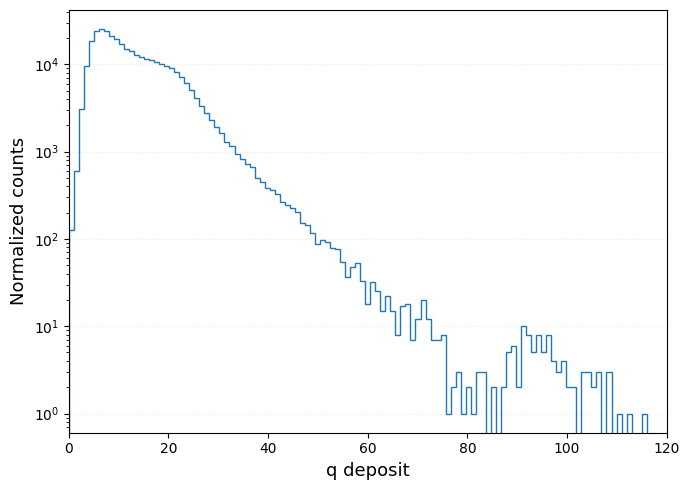

In [11]:
bins = np.linspace(0, 120, 120)
plt.figure(figsize=(7,5))
plt.hist(q, bins=bins, histtype="step")
plt.xlabel("q deposit", fontsize=13)
plt.ylabel("Normalized counts", fontsize=13)
plt.xlim(0,120)
plt.yscale("log")
#plt.tick_params(axis="both", which="major", labelsize=12)
plt.grid(axis="y", which="major", linestyle=":", alpha=0.25)
#plt.legend(fontsize=12, frameon=True,
#           facecolor="white", edgecolor="0.6")
plt.tight_layout()
plt.show()

In [12]:
def get_root_pixel_df(root_path, tree_name="PixelEDep"):

    cols = ["EventID", "EnergyDep", "EnergyDep_Primary",
            "EnergyDep_Primary_only", "EnergyDep_Secondary_only",
            "x", "y", "z",
            "x_start", "y_start", "z_start",
            "x_end", "y_end", "z_end"]

    with uproot.open(root_path) as f:
        arr = f[tree_name].arrays(cols, library="np")

    return pd.DataFrame(arr)


def obtain_muon_dqdx(f, track_index, source="h5",
                     r_dis=2.0, track_dx=2.0,
                     qmin=0.0, energy_col="EnergyDep"):

    if source == "h5":
        tr = f["analysis/rock_muon_tracks/data"][track_index]
        all_hits, ev_idx = get_track_event_hits(f, track_index)

        if len(all_hits) == 0:
            return np.array([]), np.array([]), np.array([])

        A = np.array([tr["x_start"], tr["y_start"], tr["z_start"]], dtype=float)
        B = np.array([tr["x_end"], tr["y_end"], tr["z_end"]], dtype=float)
        P = np.vstack([all_hits["x"], all_hits["y"], all_hits["z"]]).T
        Q = all_hits["Q"]

    elif source == "root":

        df_evt = f[f["EventID"] == track_index]

        if len(df_evt) == 0:
            return np.array([]), np.array([]), np.array([])

        A = np.array([df_evt["x_start"].iloc[0],df_evt["y_start"].iloc[0],df_evt["z_start"].iloc[0]], dtype=float)

        B = np.array([df_evt["x_end"].iloc[0],df_evt["y_end"].iloc[0],df_evt["z_end"].iloc[0]], dtype=float)

        P = np.vstack([df_evt["x"], df_evt["y"], df_evt["z"]]).T
        Q = df_evt[energy_col].to_numpy()

    AB = B - A
    L  = np.linalg.norm(AB)

    if L == 0 or not np.isfinite(L):
        return np.array([]), np.array([]), np.array([])

    u = AB / L
    s = (P - A) @ u

    d = point_to_segment_distance(P, A, B)
    goodQ = np.isfinite(Q) & (Q >= qmin)
    mask = goodQ & (d <= r_dis) & (s >= 0.0) & (s <= L)

    s_sel = s[mask]
    Q_sel = Q[mask]

    win  = float(track_dx)
    step = win / 2

    s_centers = np.arange(0.5 * win, L - 0.5 * win + 1e-9, step)

    dqdx = []
    cnt = []

    for sc in s_centers:
        sel = np.abs(s_sel - sc) <= 0.5 * win
        Qsum = np.sum(Q_sel[sel])
        cnt.append(Q_sel[sel].size)
        dqdx.append(Qsum / win)

    dqdx = np.array(dqdx)
    cnt = np.array(cnt)

    s_centers = s_centers[cnt > 3]
    dqdx = dqdx[cnt > 3]
    cnt = cnt[cnt > 3]

    return L - s_centers, dqdx, cnt

In [13]:
dqdx=[]
for track_index in range(len(f["analysis/rock_muon_tracks/data"])):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    all_hits, ev_idx = get_track_event_hits(f, track_index)
    A = np.array([tr["x_start"], tr["y_start"], tr["z_start"]], dtype=float)
    B = np.array([tr["x_end"], tr["y_end"], tr["z_end"]], dtype=float)
    through = both_endpoints_on_boundary(A,B,tol=1.0)
    if (through):
        s_track,dqdx_track,cnt = obtain_muon_dqdx(f, track_index,source="h5",r_dis=3.0, track_dx=2.,qmin=0)
        dqdx.append(dqdx_track)

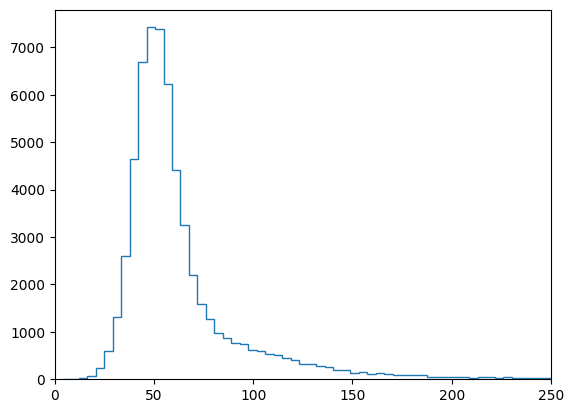

In [14]:
plt.hist(np.concatenate(dqdx), bins=200,histtype="step")
plt.xlim(0,250)
plt.show()

In [15]:
mc_0 = get_root_pixel_df(file1)
dqdx_0 = []
for event_id in mc_0["EventID"].unique():
    s_track, dqdx_track, cnt = obtain_muon_dqdx(mc_0,event_id,source="root",r_dis=3.0,track_dx=2.0,qmin=0.0,energy_col="EnergyDep")
    if len(dqdx_track) > 0:
        dqdx_0.append(dqdx_track)

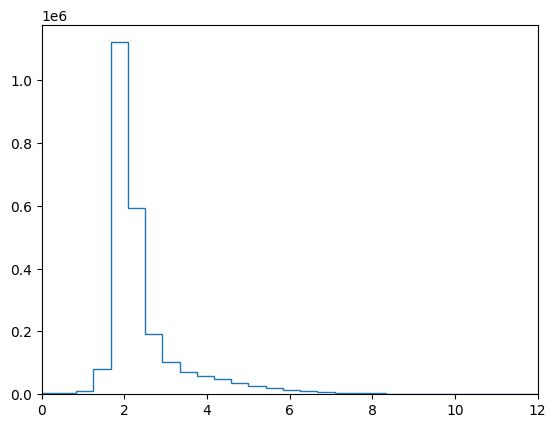

In [16]:
plt.hist(np.concatenate(dqdx_0), bins=200,histtype="step")
plt.xlim(0,12)
plt.show()

In [17]:
mc_rand = get_root_pixel_df(file2)
dqdx_rand = []
for event_id in mc_rand["EventID"].unique():
    s_track, dqdx_track, cnt = obtain_muon_dqdx(mc_rand,event_id,source="root",r_dis=3.0,track_dx=2.0,qmin=0.0,energy_col="EnergyDep")
    if len(dqdx_track) > 0:
        dqdx_rand.append(dqdx_track)

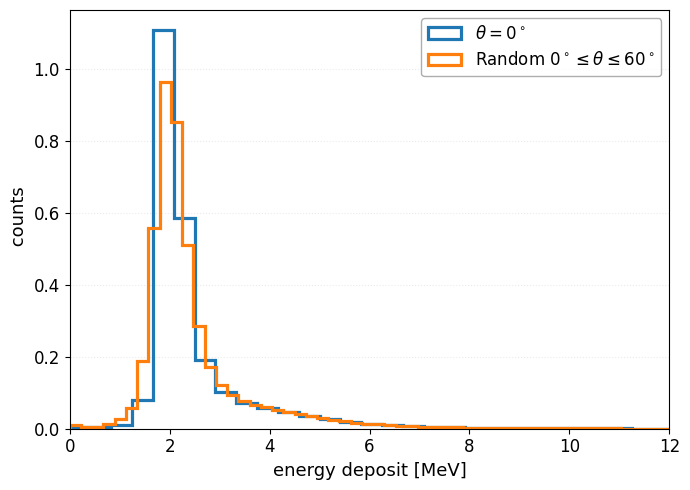

In [18]:
plt.figure(figsize=(7,5))
plt.hist(np.concatenate(dqdx_0), bins=200, histtype="step",
         color="tab:blue", linewidth=2.3,density=True,
         label=r"$\theta=0^\circ$")

plt.hist(np.concatenate(dqdx_rand), bins=200, histtype="step",
         color="tab:orange", linewidth=2.3,density=True,
         label=r"Random $0^\circ\leq\theta\leq60^\circ$")
plt.xlabel("energy deposit [MeV]", fontsize=13)
plt.ylabel(" counts", fontsize=13)
plt.xlim(0,12)
#plt.yscale("log")
plt.tick_params(axis="both", which="major", labelsize=12)
plt.grid(axis="y", which="major", linestyle=":", alpha=0.25)
plt.legend(fontsize=12, frameon=True,
           facecolor="white", edgecolor="0.6")
plt.tight_layout()
plt.show()

In [19]:
def landau_gaus(x, A, mpv, eta, sigma):
    return A * pylandau.langau(x, mpv, eta, sigma)


In [20]:
x = np.concatenate(dqdx)

counts, edges = np.histogram(x, bins=200)
centers = 0.5 * (edges[:-1] + edges[1:])

fit_mask = (centers > 30) & (centers < 80)

p0 = [counts.sum(), 48.,6.,5.]
bounds = ([0, 30, 0.1, 0.1],[np.inf, 80, 50, 50])
popt, pcov = curve_fit(landau_gaus,centers[fit_mask],counts[fit_mask],p0=p0,bounds=bounds,maxfev=50000)

A_fit, mpv_fit, eta_fit, sigma_fit = popt
err = np.sqrt(np.diag(pcov))

print("MPV   =", mpv_fit, "+/-", err[1])
print("eta   =", eta_fit, "+/-", err[2])
print("sigma =", sigma_fit, "+/-", err[3])
print("relative gaussian sigma =", sigma_fit / mpv_fit)

MPV   = 49.51942512483053 +/- 0.12895510294293533
eta   = 3.2642620792935504 +/- 0.24980396190158352
sigma = 7.974501843509412 +/- 0.3172708867651799
relative gaussian sigma = 0.16103785178052796


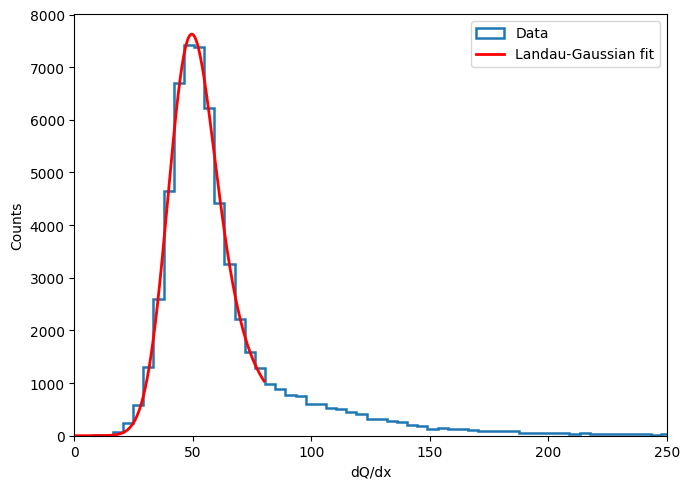

In [21]:
xx = np.linspace(0, 80, 1000)

plt.figure(figsize=(7,5))
plt.hist(x, bins=200, histtype="step", linewidth=1.8, label="Data")
plt.plot(xx, landau_gaus(xx, *popt), "r-", linewidth=2, label="Landau-Gaussian fit")
plt.xlim(0,250)
plt.xlabel("dQ/dx")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
def smear_energy(E, rel_sigma=0.161, seed=123):
    rng = np.random.default_rng(seed)
    E_smear = E * rng.normal(1.0, rel_sigma, size=len(E))
    return np.clip(E_smear, 0, None)

In [23]:
mc_0_smear = mc_0.copy()
mc_0_smear["EnergyDep_smear"] = smear_energy(mc_0_smear["EnergyDep"].to_numpy(), rel_sigma=0)
mc_rand_smear = mc_rand.copy()
mc_rand_smear["EnergyDep_smear"] = smear_energy(mc_rand_smear["EnergyDep"].to_numpy(), rel_sigma=0)

In [24]:
dqdx_0_smear = []
for event_id in mc_0_smear["EventID"].unique():
    s_track, dqdx_track, cnt = obtain_muon_dqdx(mc_0_smear,event_id,source="root",r_dis=3.0,track_dx=2.0,qmin=0.0,energy_col="EnergyDep_smear")
    if len(dqdx_track) > 0:
        dqdx_0_smear.append(dqdx_track)
dqdx_rand_smear = []
for event_id in mc_rand_smear["EventID"].unique():
    s_track, dqdx_track, cnt = obtain_muon_dqdx(mc_rand_smear,event_id,source="root",r_dis=3.0,track_dx=2.0,qmin=0.0,energy_col="EnergyDep_smear")
    if len(dqdx_track) > 0:
        dqdx_rand_smear.append(dqdx_track)

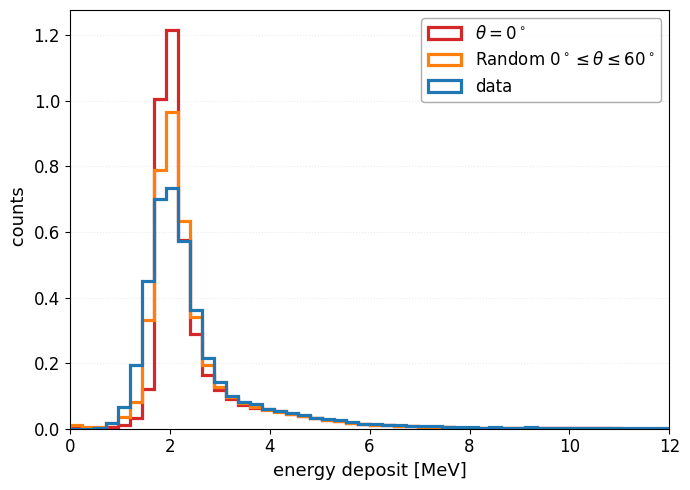

In [32]:
plt.figure(figsize=(7,5))
plt.hist(np.concatenate(dqdx_0_smear), bins=50, histtype="step",range=(0,12),
         color="tab:red", linewidth=2.3,density=True,
         label=r"$\theta=0^\circ$")

plt.hist(np.concatenate(dqdx_rand_smear), bins=50, histtype="step",range=(0,12),
         color="tab:orange", linewidth=2.3,density=True,
         label=r"Random $0^\circ\leq\theta\leq60^\circ$")
plt.hist(np.concatenate(dqdx)* (1.95 / 49.5), bins=50,histtype="step",label="data",linewidth=2.3,density = True,range=(0, 12))

plt.xlabel("energy deposit [MeV]", fontsize=13)
plt.ylabel(" counts", fontsize=13)
plt.xlim(0,12)
#plt.yscale("log")
plt.tick_params(axis="both", which="major", labelsize=12)
plt.grid(axis="y", which="major", linestyle=":", alpha=0.25)
plt.legend(fontsize=12, frameon=True,
           facecolor="white", edgecolor="0.6")
plt.tight_layout()
plt.show()

In [178]:
x_0 = np.concatenate(dqdx_0_smear)

counts, edges = np.histogram(x_0, bins=200,density= True)
centers = 0.5 * (edges[:-1] + edges[1:])

fit_mask = (centers > 1) & (centers < 3)

p0 = [counts.max(), 2.,.13,.32]
bounds = ([0, 1, 0.01, 0.01],[np.inf, 4., 2., 2.])
popt_0, pcov_0 = curve_fit(landau_gaus,centers[fit_mask],counts[fit_mask],p0=p0,bounds=bounds,maxfev=50000)

A_fit, mpv_fit, eta_fit, sigma_fit = popt_0
err = np.sqrt(np.diag(pcov_0))

print("MPV   =", mpv_fit, "+/-", err[1])
print("eta   =", eta_fit, "+/-", err[2])
print("sigma =", sigma_fit, "+/-", err[3])
print("relative gaussian sigma =", sigma_fit / mpv_fit)

MPV   = 1.9474584306458096 +/- 0.0072337837576275455
eta   = 0.11702935406753659 +/- 0.013207438188189168
sigma = 0.1867476876217331 +/- 0.018091893767928673
relative gaussian sigma = 0.09589302892581099


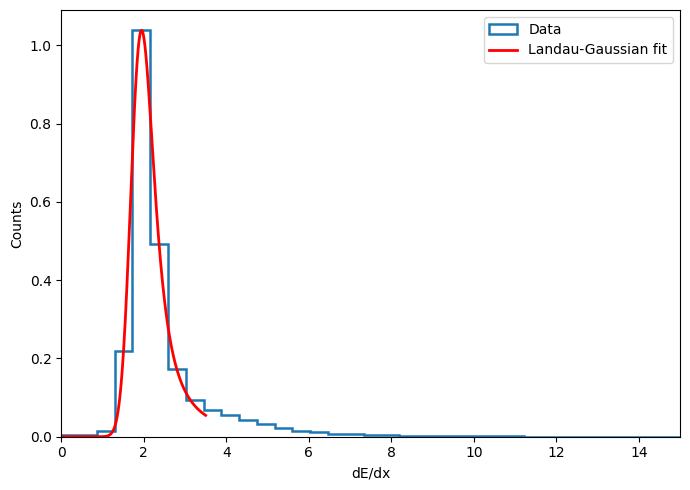

In [180]:
xx_0 = np.linspace(0, 3.5, 1000)

plt.figure(figsize=(7,5))
plt.hist(x_0, bins=200, histtype="step", linewidth=1.8, label="Data",density=True)
plt.plot(xx_0, landau_gaus(xx_0, *popt_0), "r-", linewidth=2, label="Landau-Gaussian fit")
plt.xlim(0,15)
plt.xlabel("dE/dx")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()

In [168]:
x_rand = np.concatenate(dqdx_rand_smear)

counts, edges = np.histogram(x_rand, bins=200,density= True)
centers = 0.5 * (edges[:-1] + edges[1:])

fit_mask = (centers > 1) & (centers < 3)

p0 = [counts.max(), 2.,.13,.32]
bounds = ([0, 1, 0.01, 0.01],[np.inf, 4., 2., 2.])
popt_rand, pcov_rand = curve_fit(landau_gaus,centers[fit_mask],counts[fit_mask],p0=p0,bounds=bounds,maxfev=50000)

A_fit, mpv_fit, eta_fit, sigma_fit = popt_rand
err = np.sqrt(np.diag(pcov_rand))

print("MPV   =", mpv_fit, "+/-", err[1])
print("eta   =", eta_fit, "+/-", err[2])
print("sigma =", sigma_fit, "+/-", err[3])
print("relative gaussian sigma =", sigma_fit / mpv_fit)

MPV   = 1.9744151116111641 +/- 0.0066692026951014885
eta   = 0.11143280823589352 +/- 0.013920805837230103
sigma = 0.2635819409267971 +/- 0.016707524330863026
relative gaussian sigma = 0.13349874571802112


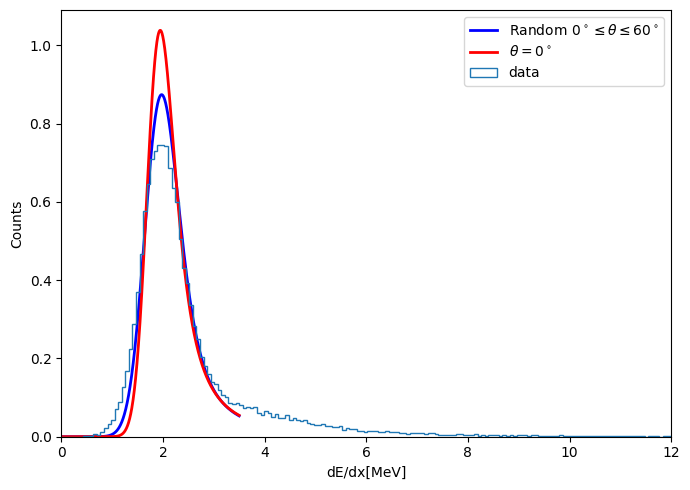

In [183]:
xx_0 = np.linspace(0, 3.5, 1000)
plt.figure(figsize=(7,5))
plt.plot(xx_0, landau_gaus(xx_0, *popt_rand), "b-", linewidth=2, label=r"Random $0^\circ\leq\theta\leq60^\circ$")
plt.plot(xx_0, landau_gaus(xx_0, *popt_0), "r-", linewidth=2, label=r"$\theta=0^\circ$")
plt.hist(np.concatenate(dqdx)* (1.95 / 49.5), bins=200,histtype="step",label="data",density = True,range=(0, 14))
plt.xlim(0,12)
plt.xlabel("dE/dx[MeV]")
plt.ylabel("Counts")
plt.legend()
plt.tight_layout()
plt.show()

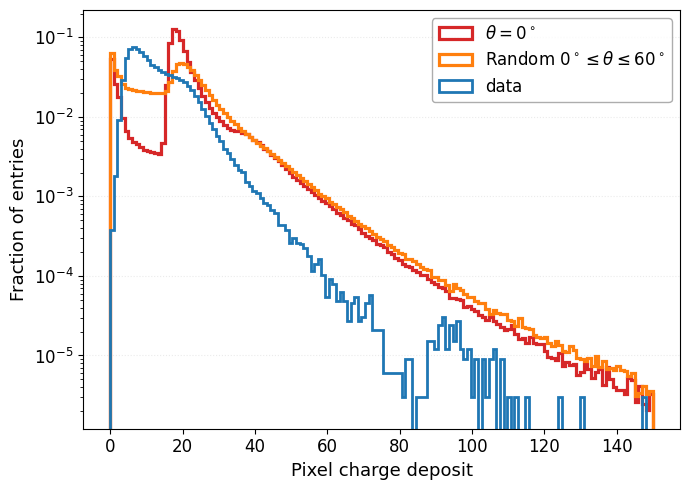

In [227]:
bins = np.linspace(0, 150, 150)

e1_scaled = e1 / (1.95 / 49.5)
e2_scaled = e2 / (1.95 / 49.5)

w1 = np.ones_like(e1_scaled) / len(e1_scaled)
w2 = np.ones_like(e2_scaled) / len(e2_scaled)
wq = np.ones_like(q) / len(q)

plt.figure(figsize=(7,5))

plt.hist(e1_scaled, bins=bins, weights=w1, histtype="step",
         color="tab:red", linewidth=2.3,
         label=r"$\theta=0^\circ$")

plt.hist(e2_scaled, bins=bins, weights=w2, histtype="step",
         color="tab:orange", linewidth=2.3,
         label=r"Random $0^\circ\leq\theta\leq60^\circ$")

plt.hist(q, bins=bins, weights=wq, histtype="step",
         linewidth=2.0, label="data")

plt.xlabel("Pixel charge deposit", fontsize=13)
plt.ylabel("Fraction of entries", fontsize=13)

plt.yscale("log")
plt.tick_params(axis="both", which="major", labelsize=12)
plt.grid(axis="y", which="major", linestyle=":", alpha=0.25)
plt.legend(fontsize=12, frameon=True, facecolor="white", edgecolor="0.6")
plt.tight_layout()
plt.show()